In [ ]:
# ===============================================
# Diabetes Risk Prediction (Improved LightGBM Model)
# ===============================================
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, precision_recall_curve, auc
)
from sklearn.preprocessing import RobustScaler
from imblearn.combine import SMOTETomek
from lightgbm import LGBMClassifier, early_stopping, log_evaluation
from skopt import BayesSearchCV
from skopt.space import Real, Integer
import warnings
warnings.filterwarnings("ignore")

In [ ]:

# ===================================================
# 1. Load & Prepare Dataset
# ===================================================
df = pd.read_csv("processed_diabetes.csv")

# Simplify diabetes outcome (binary)
df["Diabetes_binary"] = df["Diabetes_012"].apply(lambda x: 0 if x == 0 else 1)

# Remove duplicates and constant columns
df = df.drop_duplicates()
df = df.loc[:, df.nunique() > 1]

# Encode categorical variables
cat_cols = df.select_dtypes(include=['object', 'category']).columns
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)

# Scale numerical features robustly (less sensitive to outliers)
num_cols = df.select_dtypes(include=[np.number]).columns.difference(["Diabetes_012", "Diabetes_binary"])
scaler = RobustScaler()
df[num_cols] = scaler.fit_transform(df[num_cols])

X = df.drop(columns=["Diabetes_012", "Diabetes_binary"])
y = df["Diabetes_binary"]

In [ ]:
# ===================================================
# 2. Split + Resample
# ===================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

In [ ]:
# Hybrid sampling: SMOTETomek (balances and cleans borderline samples)
print("Before resampling:\n", y_train.value_counts())
sampler = SMOTETomek(random_state=42)
X_res, y_res = sampler.fit_resample(X_train, y_train)
print("After resampling:\n", y_res.value_counts())

# ===================================================
# 3. Bayesian Hyperparameter Optimization
# ===================================================
base_model = LGBMClassifier(
    objective='binary',
    random_state=42,
    class_weight='balanced',
    boosting_type='gbdt',
    n_estimators=1500,
    verbose=-1
)

param_space = {
    'num_leaves': Integer(31, 127),
    'max_depth': Integer(5, 15),
    'learning_rate': Real(0.005, 0.1, prior='log-uniform'),
    'subsample': Real(0.6, 1.0),
    'colsample_bytree': Real(0.6, 1.0),
    'min_child_samples': Integer(10, 100),
    'reg_lambda': Real(0.0, 5.0),
    'reg_alpha': Real(0.0, 2.0),
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
opt = BayesSearchCV(
    estimator=base_model,
    search_spaces=param_space,
    cv=cv,
    n_iter=25,
    scoring='f1',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print("\n Running Bayesian Optimization...")
opt.fit(X_res, y_res)
best_model = opt.best_estimator_
print("\n Best Parameters:")
print(opt.best_params_)

In [ ]:
# ===================================================
# 4. Train Best Model with Early Stopping
# ===================================================
best_model.fit(
    X_res, y_res,
    eval_set=[(X_test, y_test)],
    eval_metric='f1',
    callbacks=[early_stopping(stopping_rounds=50), log_evaluation(0)]
)

In [ ]:
# ===================================================
# 5. Predict + Optimize Threshold
# ===================================================
y_proba = best_model.predict_proba(X_test)[:, 1]

prec, rec, thresh = precision_recall_curve(y_test, y_proba)
f1_scores = 2 * (prec * rec) / (prec + rec)
best_thresh = thresh[np.nanargmax(f1_scores)]
y_pred_opt = (y_proba >= best_thresh).astype(int)

print(f"\nOptimized Threshold: {best_thresh:.4f}")
print("\nClassification Report (Optimized Threshold):")
print(classification_report(y_test, y_pred_opt, zero_division=0))

In [ ]:
# ===================================================
# 6. Evaluation Metrics
# ===================================================
cm = confusion_matrix(y_test, y_pred_opt)
roc_auc = roc_auc_score(y_test, y_proba)

print("\nConfusion Matrix:\n", cm)
print(f"\nROC-AUC: {roc_auc:.4f}")

Before resampling:
 Diabetes_binary
0    151016
1     31768
Name: count, dtype: int64
After resampling:
 Diabetes_binary
0    150113
1    150113
Name: count, dtype: int64

🔎 Running Bayesian Optimization...
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each o

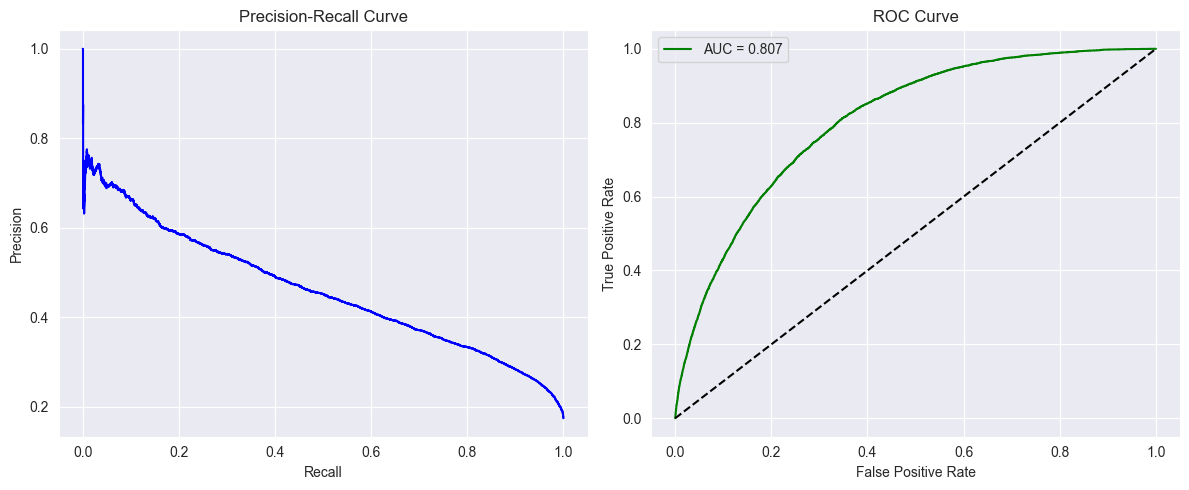

In [3]:
# ===================================================
# 7. Visualization
# ===================================================
fpr, tpr, _ = roc_curve(y_test, y_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
plt.plot(rec, prec, color='blue')
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")

plt.subplot(1, 2, 2)
plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}", color='green')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.tight_layout()
plt.show()

In [5]:
import joblib
joblib.dump(best_model, "ml_model/diabetes_model.pkl")

['ml_model/diabetes_model.pkl']